In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# 1. Introduction

In [3]:
import pandas as pd

print("Pandas version:", pd.__version__)

Pandas version: 2.3.3


Pandas is used for data manipulation and analysis, especially with tabular data.

# 2. Creating Data

In [4]:
# Series
s = pd.Series([10, 20, 30])

# DataFrame
data = {
    "Name": ["Alice", "Bob", "Charlie"],
    "Marks": [85, 90, 78]
}

df = pd.DataFrame(data)
print(df)

      Name  Marks
0    Alice     85
1      Bob     90
2  Charlie     78


# 3. Reading Data

In [21]:
# CSV file
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")

df.head()

# Excel file
# df = pd.read_excel("data.xlsx")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 4. Exploring Data

In [23]:
print(df.head())      # First 5 rows

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [24]:
print(df.tail())      # Last 5 rows

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [25]:
print(df.info())      # Structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [26]:
print(df.describe())  # Statistics

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


# 5. Selecting Data

In [7]:
# Column
print(df["Name"])

# Multiple columns
print(df[["Name", "Marks"]])

# Row selection
print(df.iloc[0])     # by index
print(df.loc[0])      # by label

0      Alice
1        Bob
2    Charlie
Name: Name, dtype: object
      Name  Marks
0    Alice     85
1      Bob     90
2  Charlie     78
Name     Alice
Marks       85
Name: 0, dtype: object
Name     Alice
Marks       85
Name: 0, dtype: object


# 6. Filtering Data

In [8]:
# Condition
filtered = df[df["Marks"] > 80]
print(filtered)

    Name  Marks
0  Alice     85
1    Bob     90


# 7. Adding & Modifying Columns

In [9]:
df["Passed"] = df["Marks"] > 50

# Update values
df["Marks"] = df["Marks"] + 5

print(df)

      Name  Marks  Passed
0    Alice     90    True
1      Bob     95    True
2  Charlie     83    True


# 8. Handling Missing Data

In [10]:
df.isnull()        # Check nulls
df.dropna()        # Remove nulls
df.fillna(0)       # Replace nulls

,Name,Marks,Passed
0,Alice,90,True
1,Bob,95,True
2,Charlie,83,True


# 9. Sorting Data

In [11]:
df.sort_values(by="Marks", ascending=False)

,Name,Marks,Passed
1,Bob,95,True
0,Alice,90,True
2,Charlie,83,True


# 10. GroupBy (Very Important)

In [12]:
data = {
    "Department": ["IT", "HR", "IT", "HR"],
    "Salary": [50000, 40000, 60000, 45000]
}

df = pd.DataFrame(data)

grouped = df.groupby("Department")["Salary"].mean()
print(grouped)

Department
HR    42500.0
IT    55000.0
Name: Salary, dtype: float64


# 11. Merging DataFrames

In [13]:
df1 = pd.DataFrame({"ID": [1,2], "Name": ["A","B"]})
df2 = pd.DataFrame({"ID": [1,2], "Marks": [90,80]})

merged = pd.merge(df1, df2, on="ID")
print(merged)

   ID Name  Marks
0   1    A     90
1   2    B     80


# 12. Iteration

In [14]:
for index, row in df.iterrows():
    print(row["Department"], row["Salary"])

IT 50000
HR 40000
IT 60000
HR 45000


# 13. Basic Visualization

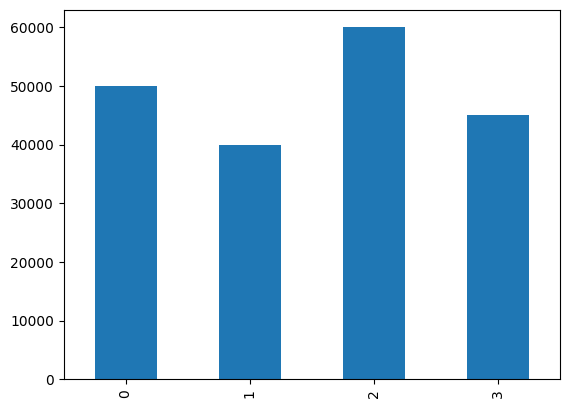

In [15]:
import matplotlib.pyplot as plt

df["Salary"].plot(kind="bar")
plt.show()